In [16]:
import numpy as np
import struct
from array import array
from os.path  import join

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        


In [17]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

input_path = './input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

In [18]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

x_train = x_train / np.max(x_train)
x_test = x_test / np.max(x_test)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [19]:
def relu(input):
    return np.maximum(0, input)

In [20]:
def softmax(input, axis=-1):
    expoent = input - np.max(input, axis=axis, keepdims=True)
    numerator = np.exp(expoent)
    denominator = np.sum(numerator, axis=axis, keepdims=True)
    probabilities = numerator / denominator
    return probabilities

In [21]:
class Layer:
    def __init__(self, weights, biases):
        self.weights = weights
        self.biases = biases
    
    def forward(self, input):
        dot_product = np.dot(input, self.weights)
        return dot_product + self.biases

class ReluLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return relu(result)

class SoftmaxLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return softmax(result)

In [22]:
def initialize_layers():
    rng = np.random.default_rng()

    input_size = x_train.shape[1]

    hidden_layer_size = 128
    hidden_layer_weights = rng.random(size=(input_size, hidden_layer_size))
    hidden_layer_biases = np.zeros(shape=(hidden_layer_size,))
    hidden_layer = ReluLayer(hidden_layer_weights, hidden_layer_biases)

    output_layer_size = 10
    output_layer_weights = rng.random(size=(hidden_layer_size, output_layer_size))
    output_layer_biases = np.zeros(shape=(output_layer_size,))
    output_layer = SoftmaxLayer(output_layer_weights, output_layer_biases)

    return hidden_layer, output_layer

In [23]:
hidden_layer, output_layer = initialize_layers()

In [24]:
def forward(input):
    hidden_layer_output = hidden_layer.forward(input)
    final_output = output_layer.forward(hidden_layer_output)
    return hidden_layer_output, final_output

In [25]:
def compute_loss(output, expected_output):
    return -np.log(output[expected_output] + 1e-9)

In [26]:
def backward(input, hidden_layer_output, final_output, expected_ouput):
    y_true_onehot = np.zeros(10)
    y_true_onehot[expected_ouput] = 1

    dL_dz_output = final_output - y_true_onehot

    dW_output = np.outer(hidden_layer_output, dL_dz_output)
    db_output = dL_dz_output

    dL_dz_hidden = np.dot(output_layer.weights, dL_dz_output) * (hidden_layer_output > 0).astype(float)

    dW_hidden = np.outer(input, dL_dz_hidden)
    db_hidden = dL_dz_hidden

    return dW_output, db_output, dW_hidden, db_hidden

In [27]:
def update_parameters(dW_output, db_output, dW_hidden, db_hidden, learning_rate=0.01):
    output_layer.weights -= dW_output * learning_rate
    output_layer.biases -= db_output * learning_rate
    hidden_layer.weights -= dW_hidden * learning_rate
    hidden_layer.biases -= db_hidden * learning_rate

In [28]:
def train(input, expected_output, learning_rate=0.01):
    hidden_layer_output, final_output = forward(input)
    loss = compute_loss(final_output, expected_output)

    dW_output, db_output, dW_hidden, db_hidden = backward(input, hidden_layer_output, final_output, expected_output)
    update_parameters(dW_output, db_output, dW_hidden, db_hidden, learning_rate)
    
    return loss

In [ ]:
def test_accuracy():
    test_size = len(x_test)
    correct_predictions = 0

    for i in range(test_size):
        _, final_output = forward(x_test[i])
        predicted_label = np.argmax(final_output)
        if predicted_label == y_test[i]:
            correct_predictions += 1
    
    accuracy = correct_predictions / test_size

    return accuracy


In [35]:
epochs = 10
learning_rate = 0.01

for epoch in range(epochs):
    train_size = len(x_train)
    total_loss = 0
    
    for i in range(train_size):
        loss = train(x_train[i], y_train[i], learning_rate)
        total_loss += loss

    avg_loss = total_loss / train_size

    print(f"Epoch {epoch + 1} finished. Avg. Loss: {avg_loss}")

accuracy = test_accuracy()
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Epoch 1 finished. Avg. Loss: 0.11048976395607552
Epoch 2 finished. Avg. Loss: 0.10488108033194597
Epoch 3 finished. Avg. Loss: 0.10255852859649714
Epoch 4 finished. Avg. Loss: 0.09504871763518676
Epoch 5 finished. Avg. Loss: 0.09052419640617136
Epoch 6 finished. Avg. Loss: 0.08610637644676213
Epoch 7 finished. Avg. Loss: 0.08308433558037441
Epoch 8 finished. Avg. Loss: 0.0795630254288139
Epoch 9 finished. Avg. Loss: 0.07628845220042307
Epoch 10 finished. Avg. Loss: 0.07390647549735671
Test Accuracy: 95.31%


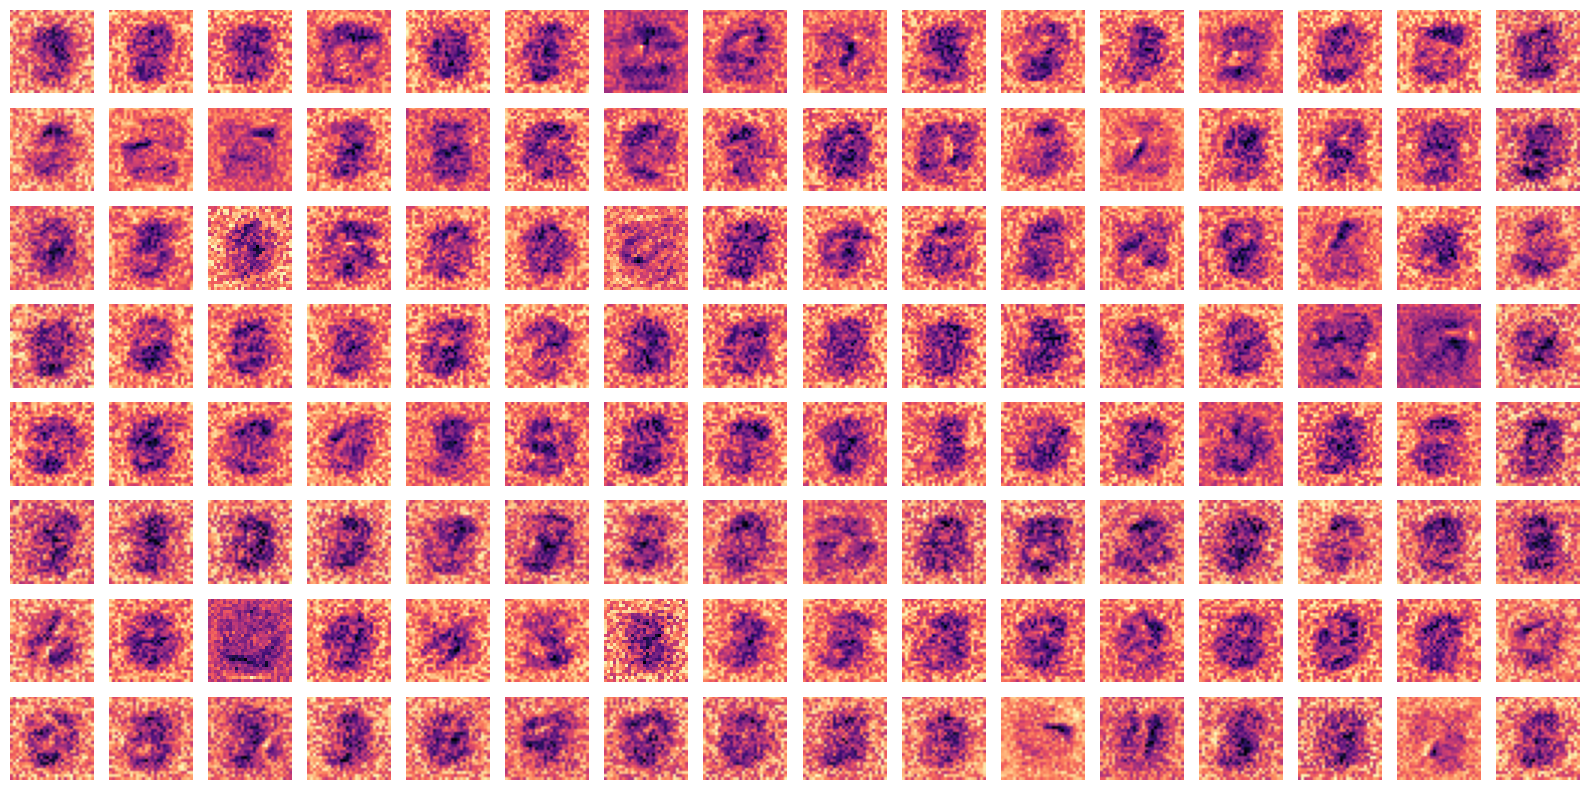

In [44]:
hidden_layer_weights = hidden_layer.weights.T
number_of_neurons = hidden_layer_weights.shape[0]

columns = 16
rows = (number_of_neurons + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(16, rows * 1))
for i in range(rows * columns):
    ax = axes.flat[i]
    if i < number_of_neurons:
        img = hidden_layer_weights[i].reshape(28, 28)
        ax.imshow(img, cmap='magma')
    ax.axis('off')

plt.tight_layout()
plt.show()